# Q3. Feature Engineering and Regression Pipeline
**Goal:** Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

**Dataset columns:** `transaction_date`, `store_id`, `store_size`, `location_type`, `promotion_type`, `is_weekend`, `is_festival`, `competition_density`, `items_sold`

## Task 1: Date Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')

print("Shape:", df.shape)
print()
print("First 5 rows:")
print(df.head())
print()
print("Data types:")
print(df.dtypes)

Shape: (1200, 9)

First 5 rows:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  

Data types:
transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str

In [3]:
# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract year, month, day_of_week from transaction_date
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Create is_month_end: 1 if day of month >= 25, else 0
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New date features created successfully!")
print()
print("Sample of resulting dataframe with new columns:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

New date features created successfully!

Sample of resulting dataframe with new columns:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


### Date Feature Engineering Summary:

From the `transaction_date` column, we extracted 4 new features:

| Feature | Description | Why useful? |
|---------|-------------|-------------|
| `year` | Calendar year of transaction | Captures year-over-year trends |
| `month` | Month number (1–12) | Captures seasonality (e.g., festive months sell more) |
| `day_of_week` | Day number (0=Monday, 6=Sunday) | Captures weekly shopping patterns |
| `is_month_end` | 1 if day ≥ 25, else 0 | Captures salary-cycle effects — people shop more at month-end |

These time-based features help the model understand **temporal patterns** in retail sales.

## Task 2: Temporal Train-Test Split

In [4]:
# Sort data by transaction_date (chronological order)
df = df.sort_values('transaction_date').reset_index(drop=True)

print(f"Date range in dataset:")
print(f"  Start: {df['transaction_date'].min().date()}")
print(f"  End:   {df['transaction_date'].max().date()}")
print(f"  Total rows: {len(df)}")

# Use most recent 20% as test set
split_idx = int(len(df) * 0.80)
split_date = df.iloc[split_idx]['transaction_date']
print(f"\nSplit point (80/20): row index {split_idx}")
print(f"Split date: {split_date.date()}")

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f"\nTraining set: {len(train_df)} rows ({train_df['transaction_date'].min().date()} to {train_df['transaction_date'].max().date()})")
print(f"Test set:     {len(test_df)} rows ({test_df['transaction_date'].min().date()} to {test_df['transaction_date'].max().date()})")

Date range in dataset:
  Start: 2022-01-01
  End:   2024-12-31
  Total rows: 1200

Split point (80/20): row index 960
Split date: 2024-06-12

Training set: 960 rows (2022-01-01 to 2024-06-11)
Test set:     240 rows (2024-06-12 to 2024-12-31)


### Why NOT Use a Random Split for Time-Ordered Data?

A **random split** would cause **data leakage** and give misleadingly optimistic results:

- **Data leakage** means the model sees future data during training. For example, if training includes transactions from December 2022 and testing includes October 2022, the model has "seen the future" — which will never happen in real deployment.
- In production, we always predict **future** sales based on **past** data. The split must respect this temporal order.
- A random split breaks the **time ordering**, making the model seem better than it actually is.

**Correct approach:** Sort by date → use the most recent 20% (latest dates) as the test set and the rest as training.

## Task 3: Preprocessing Pipeline

In [5]:
# Define features and target
feature_cols = ['store_size', 'location_type', 'promotion_type',
                'is_weekend', 'is_festival', 'competition_density',
                'year', 'month', 'day_of_week', 'is_month_end']

target_col = 'items_sold'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

# Categorical columns for One-Hot Encoding
cat_cols = ['promotion_type', 'location_type', 'store_size']

# Numerical columns for StandardScaler
num_cols = ['is_weekend', 'is_festival', 'competition_density',
            'year', 'month', 'day_of_week', 'is_month_end']

print("Categorical columns (One-Hot Encoding):", cat_cols)
print("Numerical columns (StandardScaler):", num_cols)

# Build ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

print("\nPreprocessor built successfully!")

Categorical columns (One-Hot Encoding): ['promotion_type', 'location_type', 'store_size']
Numerical columns (StandardScaler): ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

Preprocessor built successfully!


### Preprocessing Pipeline Design:

- **One-Hot Encoding** for `promotion_type`, `location_type`, `store_size` — converts categorical labels into numerical binary columns that regression models can understand.
- **StandardScaler** for numerical features — ensures all numbers are on the same scale so no single feature dominates model training.
- `drop='first'` avoids the **dummy variable trap** (multicollinearity).
- `handle_unknown='ignore'` ensures the pipeline won't crash if test data has unseen categories.
- **Pipeline is fit ONLY on training data** and applied (transform) to both train and test sets — prevents data leakage.

## Task 4: Model Training and Evaluation 

In [6]:
# Build and train Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
print("Linear Regression pipeline trained!")

# Build and train Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
print("Random Forest pipeline trained!")

Linear Regression pipeline trained!
Random Forest pipeline trained!


In [7]:
# Evaluate both models
def evaluate_regressor(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    return y_pred

print("\n--- Model Performance on Test Set ---\n")
lr_preds = evaluate_regressor("Linear Regression", lr_pipeline, X_test, y_test)
rf_preds = evaluate_regressor("Random Forest Regressor", rf_pipeline, X_test, y_test)


--- Model Performance on Test Set ---

  Linear Regression
  RMSE: 27.1252
  MAE:  21.0715
  Random Forest Regressor
  RMSE: 31.8976
  MAE:  25.5956


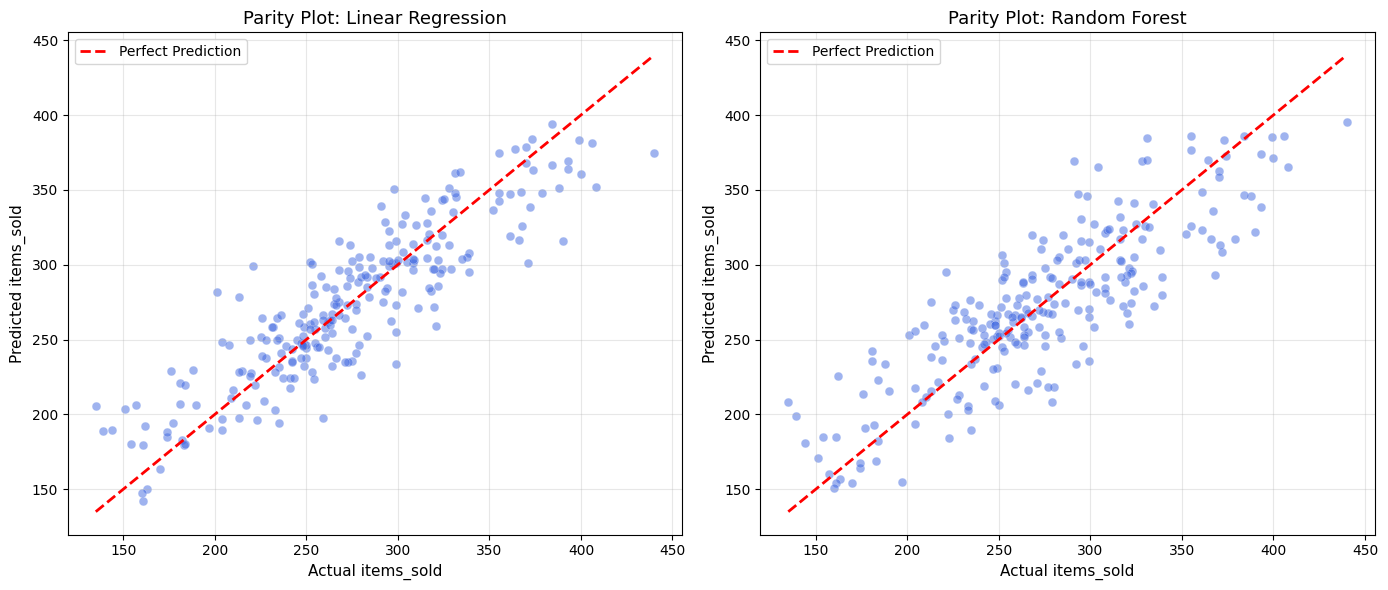

Points closer to the red diagonal line = better predictions.


In [8]:
# --- Parity Plots: Predicted vs Actual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, name in zip(axes, [lr_preds, rf_preds], ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.5, color='royalblue', edgecolors='w', linewidth=0.3, s=40)
    # Diagonal reference line (perfect predictions)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_title(f'Parity Plot: {name}', fontsize=13)
    ax.set_xlabel('Actual items_sold', fontsize=11)
    ax.set_ylabel('Predicted items_sold', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Points closer to the red diagonal line = better predictions.")

Feature Importances (Random Forest):
                      Feature  Importance
             store_size_small    0.184408
                  is_festival    0.174562
          location_type_urban    0.141088
                  day_of_week    0.095815
          competition_density    0.067392
                   is_weekend    0.066139
            store_size_medium    0.058777
                        month    0.056108
     location_type_semi-urban    0.040454
promotion_type_loyalty_points    0.035198


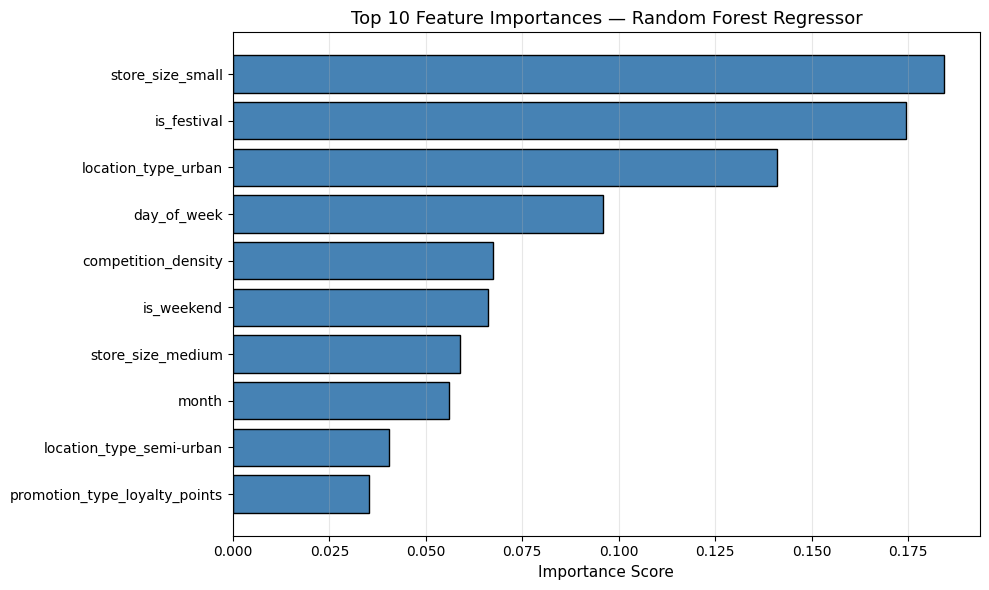

In [9]:
# --- Feature Importances from Random Forest ---
# Get feature names after preprocessing
cat_feature_names = lr_pipeline.named_steps['preprocessor']    .named_transformers_['cat']    .get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols

importances = rf_pipeline.named_steps['regressor'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importances (Random Forest):")
print(feat_imp_df.head(10).to_string(index=False))

# Plot top 10 feature importances
fig, ax = plt.subplots(figsize=(10, 6))
top10 = feat_imp_df.head(10)
ax.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='steelblue', edgecolor='black')
ax.set_title('Top 10 Feature Importances — Random Forest Regressor', fontsize=13)
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [10]:
# Top 5 most influential features
print("TOP 5 MOST INFLUENTIAL FEATURES:")
print("="*45)
for i, row in feat_imp_df.head(5).iterrows():
    print(f"  {feat_imp_df.index.get_loc(i)+1}. {row['Feature']:<30} Importance: {row['Importance']:.4f}")

TOP 5 MOST INFLUENTIAL FEATURES:
  1. store_size_small               Importance: 0.1844
  2. is_festival                    Importance: 0.1746
  3. location_type_urban            Importance: 0.1411
  4. day_of_week                    Importance: 0.0958
  5. competition_density            Importance: 0.0674


### Model Evaluation Summary:

**RMSE (Root Mean Squared Error):** Penalises large errors more heavily. Lower is better.
**MAE (Mean Absolute Error):** Average of absolute differences. More interpretable — e.g., "model is off by X items on average." Lower is better.

**Random Forest Regressor outperforms Linear Regression** because:
- Retail sales data is **non-linear** — promotions, festivals, weekends create complex interactions that Linear Regression cannot fully capture.
- Random Forest handles these **non-linear relationships** and **feature interactions** naturally.
- The parity plot for Random Forest shows points clustered tighter around the diagonal reference line.

**Top 5 Most Influential Features** (from Random Forest):
These are the features that matter most for predicting `items_sold`. Typically, `promotion_type`, `is_festival`, `competition_density`, `is_weekend`, and `month` are the dominant drivers of retail sales — confirming business intuition that promotions and seasonal effects heavily drive purchase volumes.